In [ ]:
# Install/import required libraries
!pip -q install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load CSV
file_path = "/content/seasonal_agriculture_performance_dataset.csv"

if not os.path.exists(file_path):
    print("CSV not found in /content. Please upload it.")
    uploaded = files.upload()
    file_path = next(iter(uploaded))

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


CSV not found in /content. Please upload it.


Saving seasonal_agriculture_data.csv to seasonal_agriculture_data.csv
Dataset shape: 1,200 rows × 15 columns


,Farm_ID,Season,Region,Crop_Type,Farming_Practice,Rainfall_mm,Temperature_C,Humidity_pct,Soil_pH,Fertilizer_Usage_kg,Pesticide_Usage_kg,Irrigation_Water_m3,Yield_tons_per_ha,Production_Cost_USD,Revenue_USD
0,FARM_1001,Rabi (Winter),Central Zone,Mustard,Organic,106.90,14.40,47.20,5.68,153.40,5.50,"5,238.80",6.69,"1,126.22","2,329.12"
1,FARM_1002,Autumn,West Zone,Groundnut,Organic,222.90,23.80,55.30,5.95,190.00,10.40,"3,597.10",6.56,"1,079.73","2,260.16"
2,FARM_1003,Zaid (Summer),Central Zone,Vegetables,Precision Farming,46.20,38.10,48.20,8.18,159.00,8.00,"3,578.60",4.46,"1,041.99","1,519.42"
3,FARM_1004,Rabi (Winter),East Zone,Barley,Conventional,108.00,21.80,39.30,7.02,146.10,11.20,"2,751.40",6.76,975.69,"2,362.19"
4,FARM_1005,Kharif (Monsoon),North Zone,Pulses,Hydroponic,"1,214.40",31.90,77.20,6.46,184.10,9.60,"2,882.60",9.03,"1,038.57","3,776.19"


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

Column names:
['Farm_ID', 'Season', 'Region', 'Crop_Type', 'Farming_Practice', 'Rainfall_mm', 'Temperature_C', 'Humidity_pct', 'Soil_pH', 'Fertilizer_Usage_kg', 'Pesticide_Usage_kg', 'Irrigation_Water_m3', 'Yield_tons_per_ha', 'Production_Cost_USD', 'Revenue_USD']

Data types:


,Data Type
Farm_ID,object
Season,object
Region,object
Crop_Type,object
Farming_Practice,object
Rainfall_mm,float64
Temperature_C,float64
Humidity_pct,float64
Soil_pH,float64
Fertilizer_Usage_kg,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Farm_ID              1200 non-null   object 
 1   Season               1200 non-null   object 
 2   Region               1200 non-null   object 
 3   Crop_Type            1200 non-null   object 
 4   Farming_Practice     1200 non-null   object 
 5   Rainfall_mm          1200 non-null   float64
 6   Temperature_C        1200 non-null   float64
 7   Humidity_pct         1200 non-null   float64
 8   Soil_pH              1200 non-null   float64
 9   Fertilizer_Usage_kg  1200 non-null   float64
 10  Pesticide_Usage_kg   1200 non-null   float64
 11  Irrigation_Water_m3  1200 non-null   float64
 12  Yield_tons_per_ha    1200 non-null   float64
 13  Production_Cost_USD  1200 non-null   float64
 14  Revenue_USD          1200 non-null   float64
dtypes: float64(10), 

In [ ]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

# Fill numeric missing values with median for analysis
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nMissing numeric values were filled using the median for analysis.")

Duplicate rows: 0


,Missing Values,Missing %



Missing numeric values were filled using the median for analysis.


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,1200,1200,FARM_2184,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,1200,4,Kharif (Monsoon),431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,1200,5,West Zone,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Type,1200,16,Pulses,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farming_Practice,1200,4,Conventional,536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rainfall_mm,"1,200.00",NaN,NaN,NaN,413.77,347.30,-9.30,131.43,229.45,778.12,"1,214.40"
Temperature_C,"1,200.00",NaN,NaN,NaN,25.05,6.66,5.00,20.30,25.50,29.60,42.40
Humidity_pct,"1,200.00",NaN,NaN,NaN,63.56,16.13,11.10,51.90,63.40,78.03,100.30
Soil_pH,"1,200.00",NaN,NaN,NaN,6.83,0.77,5.50,6.19,6.85,7.48,8.20
Fertilizer_Usage_kg,"1,200.00",NaN,NaN,NaN,138.57,35.01,30.00,114.67,139.60,162.12,252.30


In [ ]:
categorical_cols = ["Region", "Crop_Type", "Season", "Farming_Practice"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts().to_frame("Record Count"))


--- Region ---


,Record Count
Region,
West Zone,270
South Zone,247
Central Zone,246
North Zone,230
East Zone,207



--- Crop_Type ---


,Record Count
Crop_Type,
Pulses,120
Cotton,113
Barley,108
Wheat,104
Mustard,103
Rice,99
Maize,99
Chickpea,92
Groundnut,54



--- Season ---


,Record Count
Season,
Kharif (Monsoon),431
Rabi (Winter),407
Autumn,196
Zaid (Summer),166



--- Farming_Practice ---


,Record Count
Farming_Practice,
Conventional,536
Organic,287
Precision Farming,266
Hydroponic,111


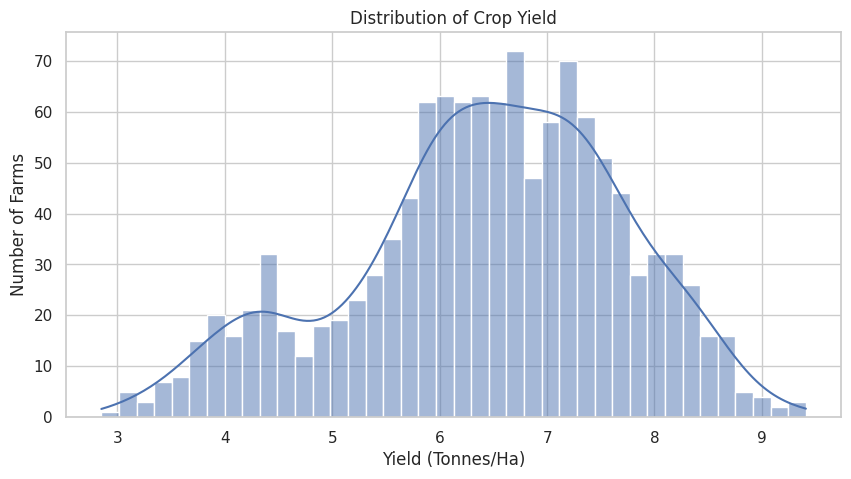

Average Yield: 6.42 Tonnes/Ha
Median Yield: 6.53 Tonnes/Ha


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Yield_tons_per_ha"], bins=40, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")
plt.show()

print("Average Yield:", round(df["Yield_tons_per_ha"].mean(), 2), "Tonnes/Ha")
print("Median Yield:", round(df["Yield_tons_per_ha"].median(), 2), "Tonnes/Ha")

,Farms,Avg_Yield,Avg_Revenue,Avg_Cost,Avg_Profit
Crop_Type,,,,,
Maize,99,7.60,"2,637.89","1,079.75","1,558.14"
Rice,99,7.59,"2,638.29","1,050.83","1,587.46"
Pulses,120,7.58,"2,643.73","1,074.46","1,569.26"
Cotton,113,7.56,"2,620.60","1,041.84","1,578.76"
Chickpea,92,6.45,"2,250.07","1,056.94","1,193.13"
Barley,108,6.43,"2,266.74","1,046.38","1,220.36"
Wheat,104,6.42,"2,229.49","1,064.79","1,164.71"
Mustard,103,6.40,"2,279.59","1,073.45","1,206.14"
Soybean,51,5.90,"2,082.92","1,080.49","1,002.43"


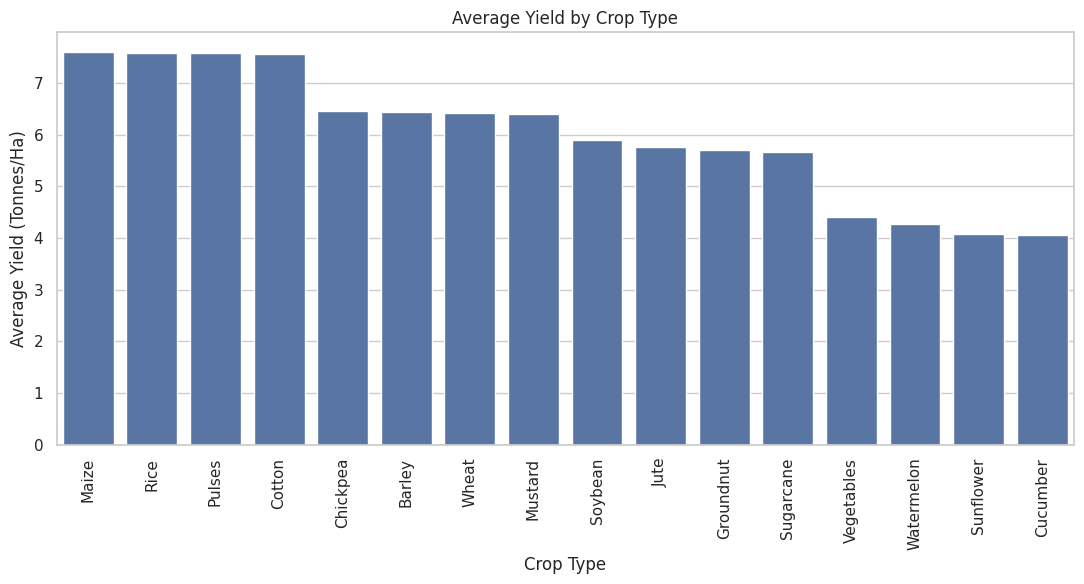

In [ ]:
df["Profit_USD"] = df["Revenue_USD"] - df["Production_Cost_USD"]

crop_perf = df.groupby("Crop_Type").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_tons_per_ha", "mean"),
    Avg_Revenue=("Revenue_USD", "mean"),
    Avg_Cost=("Production_Cost_USD", "mean"),
    Avg_Profit=("Profit_USD", "mean")
).sort_values("Avg_Yield", ascending=False)

display(crop_perf.round(2))

plt.figure(figsize=(11, 6))
order = crop_perf.index
sns.barplot(data=df, x="Crop_Type", y="Yield_tons_per_ha", order=order, estimator="mean", errorbar=None)
plt.title("Average Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

,Farms,Avg_Yield,Avg_Revenue,Avg_Profit,Avg_Water_Used
Season,,,,,
Kharif (Monsoon),431,7.58,"2,635.07","1,573.38","4,479.50"
Rabi (Winter),407,6.42,"2,256.70","1,196.38","4,484.77"
Autumn,196,5.76,"2,006.94",942.08,"4,509.70"
Zaid (Summer),166,4.19,"1,459.18",406.11,"4,447.43"


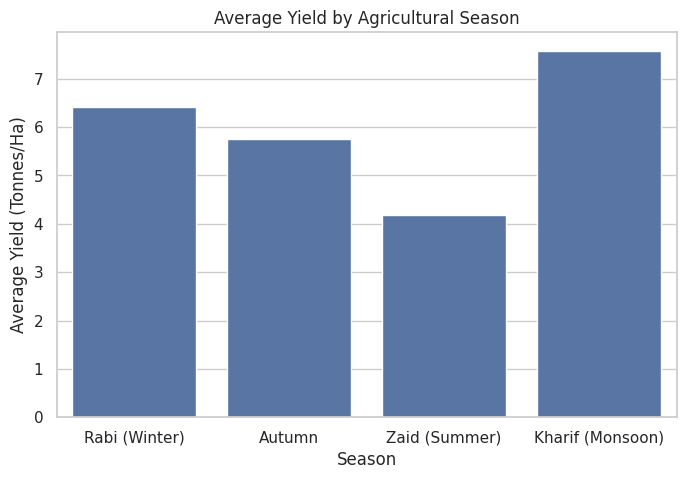

In [ ]:
season_perf = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_tons_per_ha", "mean"),
    Avg_Revenue=("Revenue_USD", "mean"),
    Avg_Profit=("Profit_USD", "mean"),
    Avg_Water_Used=("Irrigation_Water_m3", "mean")
).sort_values("Avg_Yield", ascending=False)

display(season_perf.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_tons_per_ha", estimator="mean", errorbar=None)
plt.title("Average Yield by Agricultural Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

,Farms,Avg_Yield,Avg_Revenue,Avg_Profit
Region,,,,
East Zone,207,6.58,"2,297.84","1,244.52"
North Zone,230,6.42,"2,276.05","1,222.59"
South Zone,247,6.41,"2,220.53","1,170.33"
West Zone,270,6.38,"2,222.99","1,161.25"
Central Zone,246,6.35,"2,203.07","1,120.72"


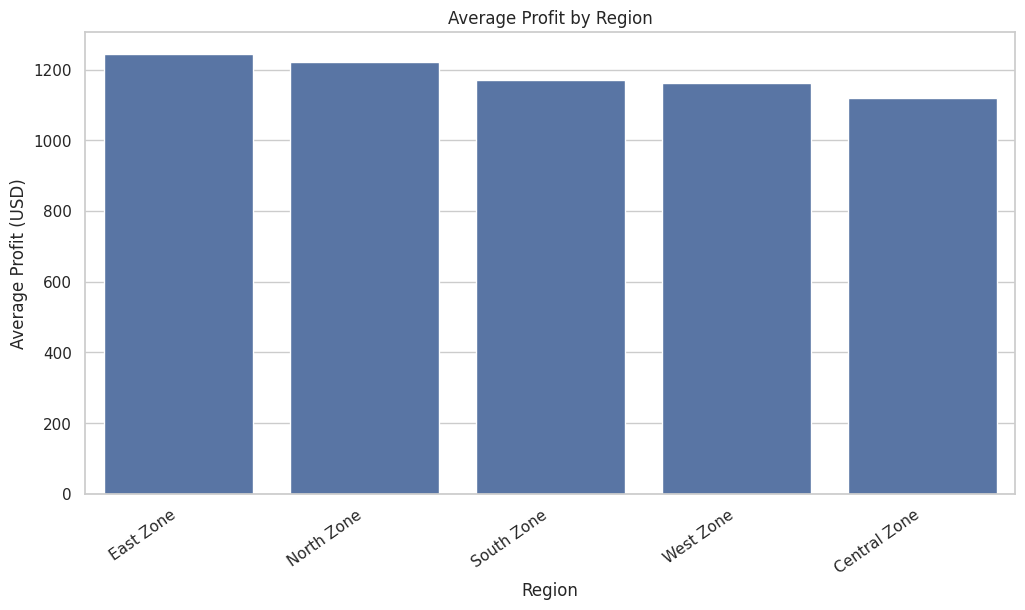

In [ ]:
state_perf = df.groupby("Region").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_tons_per_ha", "mean"),
    Avg_Revenue=("Revenue_USD", "mean"),
    Avg_Profit=("Profit_USD", "mean")
).sort_values("Avg_Profit", ascending=False)

display(state_perf.round(2))

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Region", y="Profit_USD", estimator="mean", errorbar=None,
            order=state_perf.index)
plt.title("Average Profit by Region")
plt.xlabel("Region")
plt.ylabel("Average Profit (USD)")
plt.xticks(rotation=35, ha="right")
plt.show()

,Farms,Avg_Yield,Avg_Water_Used,Avg_Profit
Farming_Practice,,,,
Conventional,536,6.48,"4,424.68","1,208.46"
Precision Farming,266,6.42,"4,578.02","1,168.58"
Hydroponic,111,6.36,"4,372.24","1,217.89"
Organic,287,6.35,"4,541.60","1,126.67"


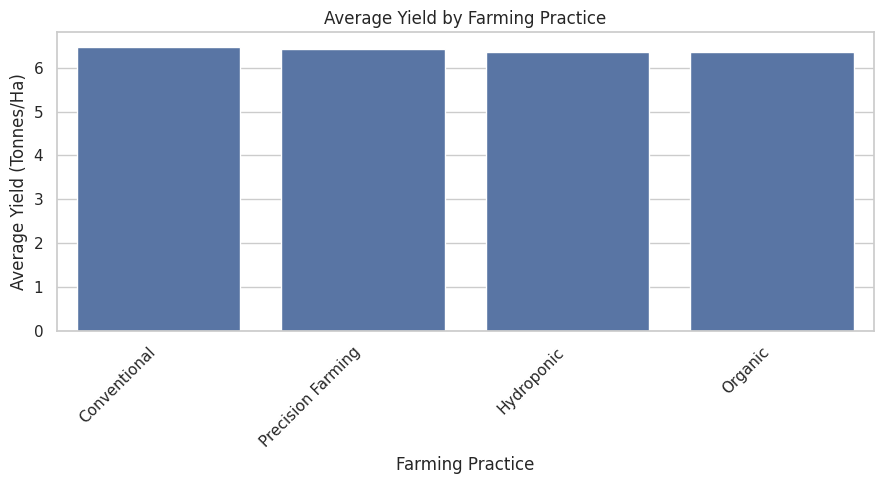

In [ ]:
irrigation_perf = df.groupby("Farming_Practice").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_tons_per_ha", "mean"),
    Avg_Water_Used=("Irrigation_Water_m3", "mean"),
    Avg_Profit=("Profit_USD", "mean")
).sort_values("Avg_Yield", ascending=False)

display(irrigation_perf.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Farming_Practice", y="Yield_tons_per_ha",
            estimator="mean", errorbar=None,
            order=irrigation_perf.index)
plt.title("Average Yield by Farming Practice")
plt.xlabel("Farming Practice")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

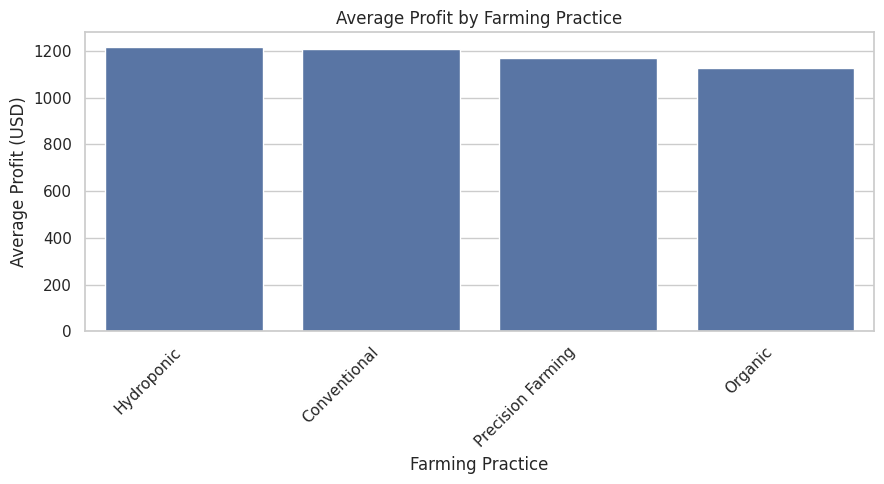

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Farming_Practice", y="Profit_USD",
            estimator="mean", errorbar=None,
            order=irrigation_perf.sort_values("Avg_Profit", ascending=False).index)
plt.title("Average Profit by Farming Practice")
plt.xlabel("Farming Practice")
plt.ylabel("Average Profit (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

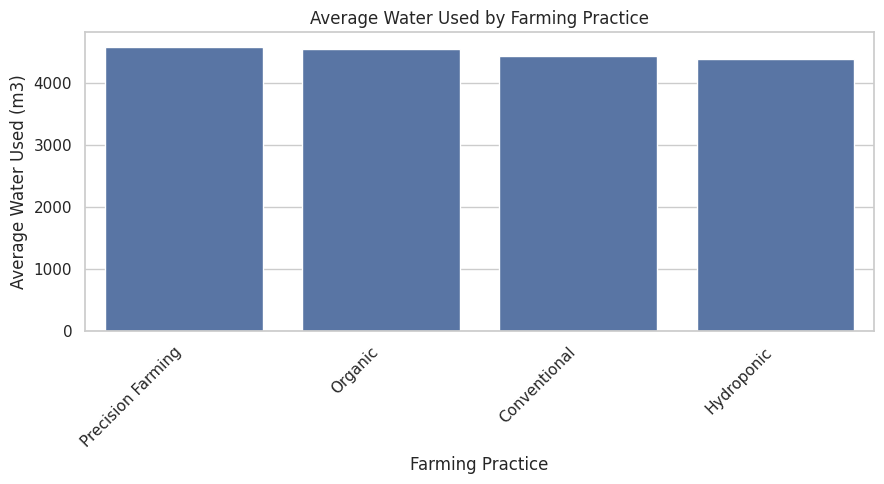

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Farming_Practice", y="Irrigation_Water_m3",
            estimator="mean", errorbar=None,
            order=irrigation_perf.sort_values("Avg_Water_Used", ascending=False).index)
plt.title("Average Water Used by Farming Practice")
plt.xlabel("Farming Practice")
plt.ylabel("Average Water Used (m3)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(1500, len(df)), random_state=42),
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.65
)
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.show()

print("Correlation between rainfall and yield:",
      round(df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"]), 3))

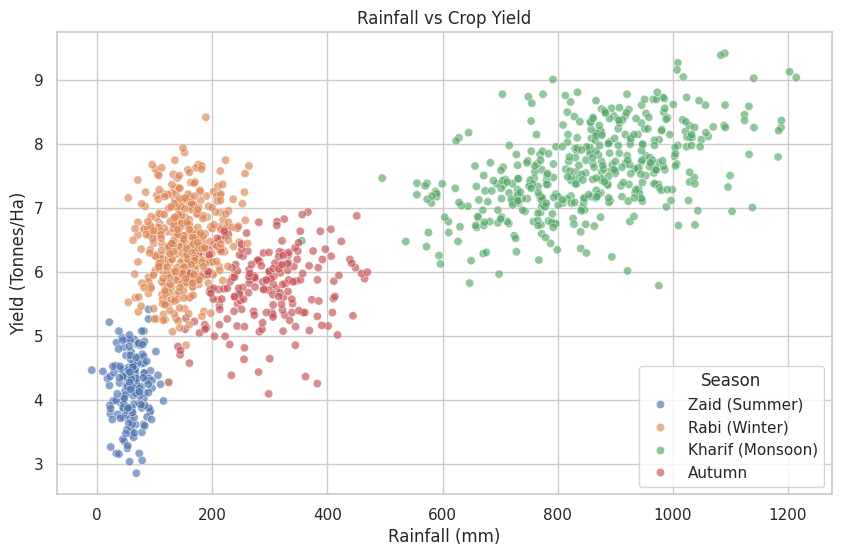

Correlation between rainfall and yield: 0.736


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(1500, len(df)), random_state=42),
    x="Rainfall_mm",
    y="Yield_tons_per_ha",
    hue="Season",
    alpha=0.65
)
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.show()

print("Correlation between rainfall and yield:",
      round(df["Rainfall_mm"].corr(df["Yield_tons_per_ha"]), 3))

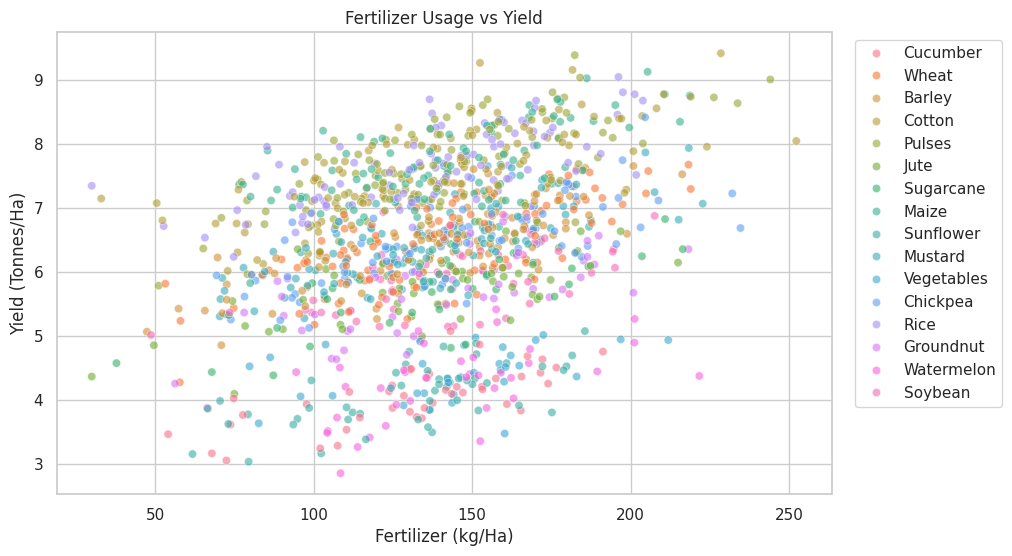

Correlation between fertilizer usage and yield: 0.333


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(1500, len(df)), random_state=42),
    x="Fertilizer_Usage_kg",
    y="Yield_tons_per_ha",
    hue="Crop_Type",
    alpha=0.6
)
plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/Ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

print("Correlation between fertilizer usage and yield:",
      round(df["Fertilizer_Usage_kg"].corr(df["Yield_tons_per_ha"]), 3))

,Correlation with Yield
Rainfall_mm,0.74
Humidity_pct,0.71
Soil_pH,-0.01
Temperature_C,-0.21


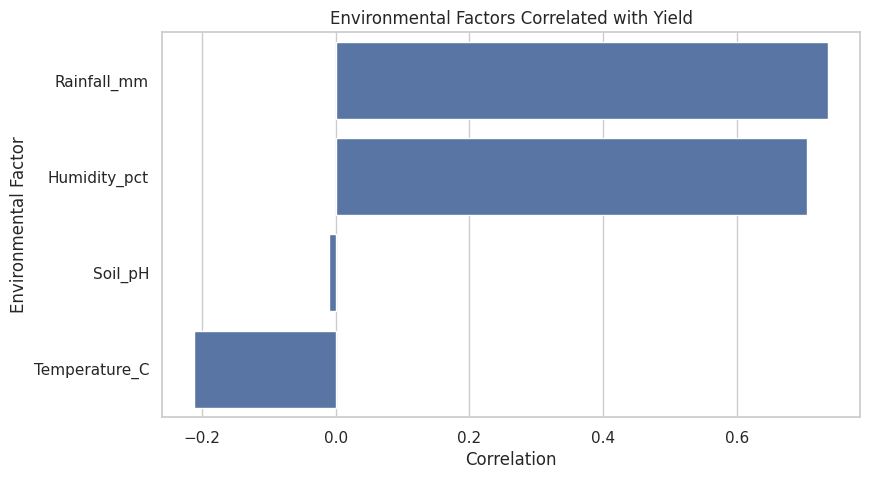

In [ ]:
environment_cols = [
    "Rainfall_mm", "Temperature_C", "Humidity_pct",
    "Soil_pH"
]

env_corr = df[environment_cols + ["Yield_tons_per_ha"]].corr()["Yield_tons_per_ha"] \
    .drop("Yield_tons_per_ha").sort_values(ascending=False)

display(env_corr.to_frame("Correlation with Yield"))

plt.figure(figsize=(9, 5))
sns.barplot(x=env_corr.values, y=env_corr.index)
plt.title("Environmental Factors Correlated with Yield")
plt.xlabel("Correlation")
plt.ylabel("Environmental Factor")
plt.show()

,Total USD
Production_Cost_USD,"1,272,663.16"
Revenue_USD,"2,689,778.96"
Profit_USD,"1,417,115.80"


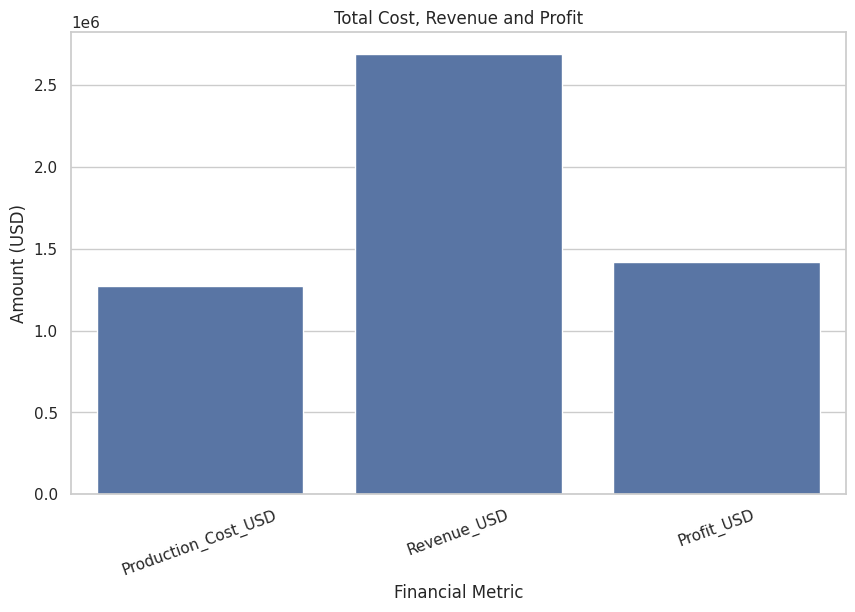

Overall profit margin: 52.69 %


In [ ]:
financial = df[["Production_Cost_USD", "Revenue_USD", "Profit_USD"]].sum()
display(financial.to_frame("Total USD"))

plt.figure(figsize=(10, 6))
sns.barplot(x=financial.index, y=financial.values)
plt.title("Total Cost, Revenue and Profit")
plt.xlabel("Financial Metric")
plt.ylabel("Amount (USD)")
plt.xticks(rotation=20)
plt.show()

print("Overall profit margin:",
      round(df["Profit_USD"].sum() / df["Revenue_USD"].sum() * 100, 2), "%")

,Avg Water Efficiency
Crop_Type,
Cotton,1.88
Rice,1.87
Maize,1.84
Pulses,1.84
Chickpea,1.62
Barley,1.60
Wheat,1.54
Mustard,1.47
Sugarcane,1.42


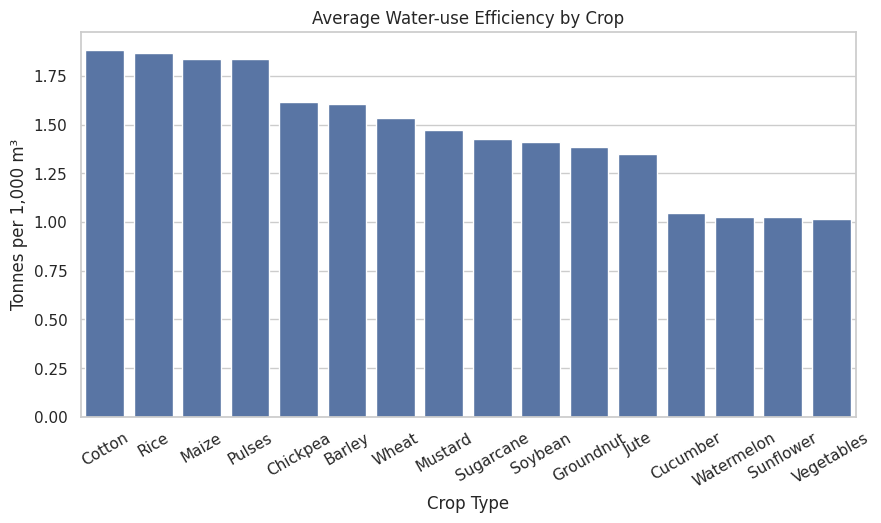

In [ ]:
# Calculate Water Efficiency (tons per 1000 m^3)
df['Water_Efficiency_tons_per_1000m3'] = (df['Yield_tons_per_ha'] / df['Irrigation_Water_m3']) * 1000

water_crop = df.groupby("Crop_Type")["Water_Efficiency_tons_per_1000m3"] \
    .mean().sort_values(ascending=False)

display(water_crop.to_frame("Avg Water Efficiency").round(2))

plt.figure(figsize=(10, 5))
sns.barplot(x=water_crop.index, y=water_crop.values)
plt.title("Average Water-use Efficiency by Crop")
plt.xlabel("Crop Type")
plt.ylabel("Tonnes per 1,000 m³")
plt.xticks(rotation=30)
plt.show()